```
ConversationBufferMemory
ConversationBufferWindowMemory
ConversationTokenBufferMemory
ConversationSummaryMemory
ConversationSummaryBufferMemory
ConversationEntityMemory
VectorStoreRetrieverMemory
CombinedMemory
ConversationStringBufferMemory
```

```
Memory Management
│
├── Short-Term Memory
│      │
│      ├── Checkpointer
│      ├── Trim
│      ├── Delete
│      ├── Summarize
│      └── Custom filtering
│
└── Long-Term Memory
       │
       ├── Store.put()
       ├── Store.get()
       ├── Store.search()
       ├── user_id / namespace
       └── Semantic retrieval
```

```
Short-Term Memory
Checkpointer → current conversation/thread ka state save karta hai so same chat ko continue kar sake.
Trim → old messages hata kar sirf recent messages LLM ko bhejta hai to reduce tokens/cost.
Delete → selected messages ko memory/state se permanently remove karta hai.
Summarize → purani long conversation ko short summary me convert karta hai.
Custom filtering → apne rule se decide karte ho kaunse messages context me rakhne hain aur kaunse nahi.

Long-Term Memory
Store.put() → koi user fact/preference/memory save karta hai.
Store.get() → exact saved memory ko key/id se retrieve karta hai.
Store.search() → stored memories me search karke relevant memories nikalta hai.
user_id / namespace → memories ko different users ya categories ke according separate rakhta hai.
Semantic retrieval → exact keywords ke instead meaning/similarity ke basis par relevant memory retrieve karta hai.
```

```
Short-Term Memory
Checkpointer → Saves the state of the current conversation/thread so the same chat can be continued.
Trim → Removes old messages and sends only recent messages to the LLM to reduce tokens/cost.
Delete → Permanently removes selected messages from memory/state.
Summarize → Converts an old, lengthy conversation into a short summary.
Custom filtering → You decide, based on your own rules, which messages should be kept in the context and which should not.

Long-Term Memory
Store.put() → Saves a user fact/preference/memory.
Store.get() → Retrieves an exact saved memory using a key/ID.
Store.search() → Searches stored memories and retrieves relevant memories.
user_id / namespace → Separates memories according to different users or categories.
Semantic retrieval → Retrieves relevant memories based on meaning/similarity instead of exact keywords.
```

What is Memory in AI?

Memory is the mechanism that allows an AI application to retain and reuse information from previous interactions.

Memory in AI is the ability of an application to store, retrieve, and reuse information from previous interactions so that the system can maintain context and provide more consistent and personalized responses.

An LLM is usually stateless by itself. If the previous context is not provided with each new call, the model does not remember the earlier conversation.

User: My name is Sunny.

AI: Nice to meet you.

User: What is my name?

Without memory:

Every request → treated like a new conversation

With memory:

Previous Context

      +

Current Query

      ↓
      
Better Response

Example:

User: I am working on Agentic RAG.

Later: What project am I working on?

Memory ke through AI answer : Agentic RAG

Two major types

Short-Term Memory

→ current conversation/session

→ recent messages

Long-Term Memory

→ information retained across conversations

→ user preferences, facts, past interactions

Why do we need Memory Management in AI Applications?

- Maintain conversation continuity
- Handle follow-up questions
- Personalize responses
- Remember user preferences
- Support long-running agent workflows
- Avoid repeated questions
- Maintain context across sessions
- Track workflow state
- Control context-window usage
- Reduce token usage and cost

In [1]:
import os
from getpass import getpass

api_key = os.getenv("OPENAI_API_KEY")

if not api_key or api_key == "YOUR_OPENAI_API_KEY":
    os.environ["OPENAI_API_KEY"] = getpass("Enter OPENAI_API_KEY: ")

print("OPENAI_API_KEY configured:", bool(os.getenv("OPENAI_API_KEY")))

OPENAI_API_KEY configured: True


In [2]:
from langchain.chat_models import init_chat_model

In [3]:
model = init_chat_model("openai:gpt-4.1-mini")

In [4]:
model.invoke([{"role": "user", "content": "Hello, how are you?"}])

AIMessage(content="Hello! I'm doing well, thank you. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 13, 'total_tokens': 29, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_49794ab4c7', 'id': 'chatcmpl-ENGFVGU8po4SybnxiozMqa4cKUYII', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a09563-5bfa-7a82-a49e-8569eaf36083-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 16, 'total_tokens': 29, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [5]:
memory = []

In [6]:
def chat(user_input:str)-> str:
    memory.append(
        {
            "role": "user",
            "content": user_input
        }
    )
    
    response = model.invoke(memory)
    
    memory.append(
        {
            "role": "assistant",
            "content": response.content
        }
    )
    return response.content


In [11]:
def run_chat_loop():

    print("Type 'exit' or 'quit' to stop.")

    while True:
        user_input = input("\nYou: ").strip()

        if user_input.lower() in {"exit","quit",}:
            print("Chat ended.")
            break

        if not user_input:
            continue

        answer = chat(user_input)

        print(
            "\nAI:",
            answer
        )


In [12]:
run_chat_loop()

Type 'exit' or 'quit' to stop.

AI: That’s great to hear, Sunny! It sounds like you’re interested in LangGraph and creating agentic workflows. Could you tell me more about what you mean by "agentic workflow"? Are you referring to designing workflows where agents (like AI agents or automated processes) take initiative and act autonomously?

Also, if you want, I can help you brainstorm ideas, design workflows, or explain concepts related to LangGraph and agentic systems. Let me know how you'd like to proceed!

AI: That’s awesome, Sunny! Creating YouTube videos is a fun and creative hobby. What kind of videos do you like to make? Are you interested in any tips for content creation, video editing, or growing your YouTube channel? I’d be happy to help!

AI: Sure, Sunny! Based on what you shared:

- You like **LangGraph** as an agentic framework.
- Your hobby is **creating YouTube videos** in your free time.

If you'd like, I can help you explore more about LangGraph or offer tips for your Y

In [13]:
memory

[{'role': 'user', 'content': 'hello how are you my name is sunny'},
 {'role': 'assistant',
  'content': "Hello Sunny! I'm doing well, thank you. How can I assist you today?"},
 {'role': 'user', 'content': 'can we disuccss something about the india gdp?'},
 {'role': 'assistant',
  'content': "Of course, Sunny! I'd be happy to discuss India's GDP with you. What specific aspects are you interested in? For example, recent trends, sector-wise contribution, comparison with other countries, or something else?"},
 {'role': 'user',
  'content': 'i would like to know about the total gdp of india'},
 {'role': 'assistant',
  'content': "Sure! As of the latest data available in 2024, India's Gross Domestic Product (GDP) is approximately **$3.7 trillion USD**, making it the **5th largest economy** in the world by nominal GDP.\n\nIndia's economy has been growing steadily over the past few years, driven by sectors like services, industry, and agriculture. The services sector contributes the most to th

In [14]:
for message in memory:
        print(
        message["role"],
        "->",
        message["content"]
    )

user -> hello how are you my name is sunny
assistant -> Hello Sunny! I'm doing well, thank you. How can I assist you today?
user -> can we disuccss something about the india gdp?
assistant -> Of course, Sunny! I'd be happy to discuss India's GDP with you. What specific aspects are you interested in? For example, recent trends, sector-wise contribution, comparison with other countries, or something else?
user -> i would like to know about the total gdp of india
assistant -> Sure! As of the latest data available in 2024, India's Gross Domestic Product (GDP) is approximately **$3.7 trillion USD**, making it the **5th largest economy** in the world by nominal GDP.

India's economy has been growing steadily over the past few years, driven by sectors like services, industry, and agriculture. The services sector contributes the most to the GDP, followed by industry and agriculture.

If you'd like, I can also provide information on India's GDP growth rate, sector-wise contribution, or GDP in t

## Problem with Full Memory

If the conversation keeps growing, sending the entire history on every request increases:

- input tokens
- cost
- latency
- context-window usage

So we normally separate **what we store** from **what we send to the LLM**.

## Sliding Window Memory


We still store the complete conversation, but only the most recent messages are sent to the LLM.

**Stored history can be large; active LLM context should stay controlled.**

In [16]:
# chatgpt

# 100 question

# 1
# 2
# 3
# 4
# 5





# 100

# 101 question 1 question sometime you will notice this chatgpt is hallucinating and giving wrong answer.

# 90 question
# 95 question

# then you will see that chatgpt is giving somewhat correct answer.

In [ ]:
full_history = [
    "M1",
    "M2",
    "M3",
    "M4",
    "M5",
    "M6",
    "M7",
    "M8",
    "M9",
    "M10"
]


In [18]:
recent_context = full_history[-6:]

In [19]:
recent_context

['M5', 'M6', 'M7', 'M8', 'M9', 'M10']

In [26]:
memory = []

In [27]:
MAX_CONTEXT_MESSAGES = 6

In [28]:
def chat(user_input: str) -> str:
    memory.append(
        {
            "role": "user",
            "content": user_input
        }
    )
    recent_context = memory[-MAX_CONTEXT_MESSAGES:]
    
    response = model.invoke(
        recent_context
    )
    memory.append(
        {
            "role": "assistant",
            "content": response.content
        }
    )
    return response.content
    

In [29]:
def run_chat_loop():
    print("Type 'exit' or 'quit' to stop.")

    while True:
        user_input = input(
            "\nYou: "
        ).strip()

        if user_input.lower() in {
            "exit",
            "quit",
        }:
            print("Chat ended.")
            break

        if not user_input:
            continue

        answer = chat(user_input)

        print(
            "\nAI:",
            answer
        )

        print(
            "\n[Full stored messages]:",
            len(memory)
        )

        print(
            "[Messages used as active context]:",
            min(
                len(memory),
                MAX_CONTEXT_MESSAGES,
            )
        )

In [30]:
run_chat_loop()

Type 'exit' or 'quit' to stop.

AI: Hello Sunny! How can I assist you today?

[Full stored messages]: 2
[Messages used as active context]: 2

AI: Hi Sunny! Yes, Python is an excellent programming language. It's known for being easy to learn, versatile, and widely used in many fields like web development, data science, machine learning, automation, and more. If you enjoy Python, you're definitely working with a great language! Do you have any specific projects or areas you're interested in?

[Full stored messages]: 4
[Messages used as active context]: 4

AI: Absolutely, Sunny! Python is a great language—it's beginner-friendly, versatile, and has a huge community. Whether you're interested in web development, data analysis, artificial intelligence, or automation, Python has powerful libraries and frameworks to support you. What do you like most about Python?

[Full stored messages]: 6
[Messages used as active context]: 6

AI: That's awesome, Sunny! Yes, I know what AI is. AI, or Artifici

# Summary + Recent Messages

Strategy:

- keep recent messages exactly as they are
- summarize older messages
- send `summary + recent messages` to the LLM
- optionally keep complete history separately for audit/storage

Compression happens only after a complete user/assistant turn, so we do not intentionally split a turn during summarization.

In [46]:
memory = []

In [47]:
conversation_summary = ""

In [48]:
MAX_RECENT_MESSAGES = 6

In [49]:
full_history = []

In [50]:
def format_messages(messages):
    if not messages:
        return "No recent conversation."

    return "\n".join(
        f"{message['role']}: {message['content']}"
        for message in messages
    )
    


In [35]:
def create_summary(old_summary: str, old_messages: list) -> str:

    conversation_text = format_messages(old_messages)

    prompt = f"""
You maintain conversation memory for an AI assistant.

Existing summary:
{old_summary or "No previous summary."}

Older conversation messages to merge:
{conversation_text}

Create one concise updated summary.

Preserve useful information such as:
- user name
- preferences
- projects
- decisions
- important facts
- important questions and answers

Ignore greetings and unnecessary small talk.
"""

    response = model.invoke(prompt)

    return response.content.strip()

In [51]:
def compress_memory_into_summary():

    global memory
    global conversation_summary

    if len(memory) <= MAX_RECENT_MESSAGES:
        return

    old_messages = memory[:-MAX_RECENT_MESSAGES]

    memory = memory[-MAX_RECENT_MESSAGES:]

    conversation_summary = create_summary(
        conversation_summary,
        old_messages
    )

In [52]:
def chat(user_input: str) -> str:

    global memory
    global full_history

    user_message = {"role": "user","content": user_input}

    memory.append(user_message)
    full_history.append(user_message)

    messages_for_llm = [{"role": "system", "content": f"""Previous conversation summary:{conversation_summary or "No previous summary."}"""},
                        *memory
                        ]
    
    response = model.invoke(messages_for_llm)

    assistant_message = {"role": "assistant","content": response.content}

    memory.append(assistant_message)
    full_history.append(assistant_message)

    # Compress only after a complete user/assistant turn
    compress_memory_into_summary()

    return response.content

In [ ]:
def chat_loop():

    print("Type 'exit' or 'quit' to stop.")

    while True:

        user_input = input("\nYou: ").strip()

        if user_input.lower() in {"exit","quit"}:
            print("Chat ended.")
            break

        if not user_input:
            continue

        answer = chat(user_input)

        print("\nAI:",answer)

        print(
            "\n[Recent active messages]:",
            len(memory)
        )

        print(
            "[Full-history messages]:",
            len(full_history)
        )

        if conversation_summary:

            print(
                "\n[Current summary]:"
            )

            print(
                conversation_summary
            )

In [40]:
chat_loop()

Type 'exit' or 'quit' to stop.

AI: Hello Sunny! I'd be happy to help you with learning. What specific subject or topic would you like to learn about?

[Recent active messages]: 2
[Full-history messages]: 2

AI: Hi Sunny! Python is indeed one of the best languages for AI development because of its simplicity and the vast number of libraries available (like TensorFlow, PyTorch, scikit-learn, etc.).

However, there are other programming languages that are also used in AI development:

1. **R** – Great for statistics and data analysis, often used in machine learning.
2. **Java** – Used in large-scale AI applications, has good tools and libraries.
3. **C++** – Offers high performance, used in game AI and real-time systems.
4. **Julia** – Designed for high-performance numerical computing, gaining popularity in AI.
5. **Lisp** – Historically important in AI research, known for symbolic processing.
6. **Prolog** – Used in logic-based AI and expert systems.

If you’re just starting, Python is 

In [5]:
state = {
    "memory": [],
    "summary": "",
    "full_history": []
}

In [6]:
MAX_RECENT_MESSAGES = 6

In [7]:
def create_summary(old_messages):

    conversation_text = "\n".join(
        f"{msg['role']}: {msg['content']}"
        for msg in old_messages
    )

    prompt = f"""
You maintain conversation memory for an AI assistant.

Existing summary:
{state["summary"] or "No previous summary."}

Older conversation:
{conversation_text}

Create one concise updated summary.
Preserve important facts, preferences, projects and decisions.
Ignore greetings and unnecessary small talk.
"""

    response = model.invoke(prompt)

    return response.content.strip()


In [8]:

def compress_memory():

    if len(state["memory"]) <= MAX_RECENT_MESSAGES:
        return

    # Everything except the latest 6 messages
    old_messages = state["memory"][:-MAX_RECENT_MESSAGES]

    # Keep only latest 6 messages
    state["memory"] = state["memory"][-MAX_RECENT_MESSAGES:]

    # Merge old information into previous summary
    state["summary"] = create_summary(old_messages)

In [9]:
def chat(user_input):

    # -------------------------
    # Store user message
    # -------------------------

    user_message = {
        "role": "user",
        "content": user_input
    }

    state["memory"].append(user_message)
    state["full_history"].append(user_message)


    # -------------------------
    # Send:
    # summary + recent messages
    # -------------------------

    messages = [
        {
            "role": "system",
            "content": f"""
Previous conversation summary:

{state["summary"] or "No previous summary."}
"""
        },
        *state["memory"]
    ]


    response = model.invoke(messages)


    # -------------------------
    # Store AI response
    # -------------------------

    assistant_message = {
        "role": "assistant",
        "content": response.content
    }

    state["memory"].append(assistant_message)
    state["full_history"].append(assistant_message)


    # Compress if memory becomes too large
    compress_memory()

    return response.content


In [10]:
def chat_loop():

    while True:

        user_input = input("\nYou: ").strip()

        if user_input.lower() in {"exit", "quit"}:
            print("Chat ended.")
            break

        if not user_input:
            continue

        answer = chat(user_input)

        print("\nAI:", answer)

        print(
            "\nRecent messages:",
            len(state["memory"])
        )

        print(
            "Full history:",
            len(state["full_history"])
        )

        if state["summary"]:
            print(
                "\nCurrent Summary:\n",
                state["summary"]
            )

In [11]:
chat_loop()


AI: Hello! How can I assist you today?

Recent messages: 2
Full history: 2

AI: Nice to meet you, Sunny! How can I help you today?

Recent messages: 4
Full history: 4

AI: Your name is Sunny. How can I assist you further?

Recent messages: 6
Full history: 6
Chat ended.


In [12]:
state

{'memory': [{'role': 'user', 'content': 'hello'},
  {'role': 'assistant', 'content': 'Hello! How can I assist you today?'},
  {'role': 'user', 'content': 'my name is sunny i live in bengalurur'},
  {'role': 'assistant',
   'content': 'Nice to meet you, Sunny! How can I help you today?'},
  {'role': 'user', 'content': 'what is my name'},
  {'role': 'assistant',
   'content': 'Your name is Sunny. How can I assist you further?'}],
 'summary': '',
 'full_history': [{'role': 'user', 'content': 'hello'},
  {'role': 'assistant', 'content': 'Hello! How can I assist you today?'},
  {'role': 'user', 'content': 'my name is sunny i live in bengalurur'},
  {'role': 'assistant',
   'content': 'Nice to meet you, Sunny! How can I help you today?'},
  {'role': 'user', 'content': 'what is my name'},
  {'role': 'assistant',
   'content': 'Your name is Sunny. How can I assist you further?'}]}

| Step        | Actual conversation                                                                                                    | `memory` after turn     | Which messages are covered by the summary | `conversation_summary` after turn                                                                            | `full_history` |
| ----------- | ---------------------------------------------------------------------------------------------------------------------- | ----------------------- | --------------------------------------- | ------------------------------------------------------------------------------------------------------------ | -------------- |
| **M1-M2**   | **User:** My name is Sunny. **AI:** Nice to meet you, Sunny.                                                           | M1 M2                   | None                                    | Empty                                                                                                        | M1-M2          |
| **M3-M4**   | **User:** I live in Bengaluru. **AI:** Got it, you live in Bengaluru.                                                  | M1 M2 M3 M4             | None                                    | Empty                                                                                                        | M1-M4          |
| **M5-M6**   | **User:** I am learning LangGraph. **AI:** Great, LangGraph is useful for stateful agent workflows.                    | M1 M2 M3 M4 M5 M6       | None                                    | Empty                                                                                                        | M1-M6          |
| **M7-M8**   | **User:** I am building an Agentic RAG project. **AI:** Nice, that combines retrieval with agentic workflows.          | M3 M4 M5 M6 M7 M8       | **M1-M2**                               | **Sunny is the user's name.**                                                                                | M1-M8          |
| **M9-M10**  | **User:** My preferred programming language is Python. **AI:** Got it, you prefer Python.                              | M5 M6 M7 M8 M9 M10      | **M1-M4**                               | **Sunny is the user's name and he lives in Bengaluru.**                                                      | M1-M10         |
| **M11-M12** | **User:** I want to use PostgreSQL for persistence. **AI:** PostgreSQL is a good choice for persistent state and data. | M7 M8 M9 M10 M11 M12    | **M1-M6**                               | **Sunny is the user's name, lives in Bengaluru, and is learning LangGraph.**                                 | M1-M12         |
| **M13-M14** | **User:** I prefer concise explanations. **AI:** Understood, I will keep explanations concise.                         | M9 M10 M11 M12 M13 M14  | **M1-M8**                               | **Sunny lives in Bengaluru, is learning LangGraph, and is building an Agentic RAG project.**                 | M1-M14         |
| **M15-M16** | **User:** What am I currently building? **AI:** You are currently building an Agentic RAG project.                     | M11 M12 M13 M14 M15 M16 | **M1-M10**                              | **Sunny lives in Bengaluru, is learning LangGraph, is building an Agentic RAG project, and prefers Python.** | M1-M16         |


In [2]:
import os
from getpass import getpass
import faiss
import numpy as np
from langchain_openai import ChatOpenAI
from sentence_transformers import SentenceTransformer

In [3]:
# ============================================================
# OPENAI SETUP
# ============================================================

api_key = os.getenv("OPENAI_API_KEY")

if not api_key or api_key == "YOUR_OPENAI_API_KEY":
    api_key = getpass("Enter OPENAI_API_KEY: ").strip()
    if not api_key:
        raise ValueError("OPENAI_API_KEY is required.")
    os.environ["OPENAI_API_KEY"] = api_key

LLM_MODEL = "gpt-4o-mini"

model = ChatOpenAI(
    model=LLM_MODEL,
    temperature=0
)

In [4]:
model.invoke([{"role": "user", "content": "Hello, how are you?"}])

AIMessage(content="Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 13, 'total_tokens': 42, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_62666fb687', 'id': 'chatcmpl-ENJgfJ4BFYxGM9mxQVAgmqovGF9Yg', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0962c-f811-70d3-9825-8a96843a2a13-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 29, 'total_tokens': 42, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reas

In [5]:

# ============================================================
# EMBEDDING MODEL + FAISS INDEX
# ============================================================

embedder = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

dimension = embedder.get_embedding_dimension()


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12335.84it/s]


In [6]:
dimension

384

In [7]:
index = faiss.IndexFlatL2(dimension)

In [8]:
documents = []

In [9]:

# ============================================================
# SHORT-TERM CONVERSATION MEMORY
# ============================================================
memory = []

In [10]:
# ============================================================
# CREATE EMBEDDING
# ============================================================
def embed(text):
    embedding = embedder.encode([text])[0]
    return embedding.astype("float32")

In [13]:
# ============================================================
# ADD DOCUMENT TO VECTOR STORE
# ============================================================
def add_document(text):
    embedding = embed(text)
    index.add(np.array([embedding]))
    documents.append(text)

In [12]:
# ============================================================
# RETRIEVE RELEVANT DOCUMENTS
# ============================================================

def retrieve(query, k=2):

    if not documents:
        return []

    query_embedding = embed(query)

    k = min(k, len(documents))

    distances, ids = index.search(
        np.array(
            [query_embedding]
        ),
        k
    )

    results = []

    for i in ids[0]:

        if i != -1:
            results.append(
                documents[i]
            )

    return results

In [19]:

# ============================================================
# GENERATE ANSWER
# ============================================================

def generate_answer(
    query,
    retrieved_documents,
    memory
):

    # Convert previous conversation into text
    memory_text = "\n".join(
        f"User: {user_query}\n"
        f"Assistant: {assistant_answer}"
        for user_query, assistant_answer in memory
    )

    if not memory_text:
        memory_text = "No previous conversation."


    # Convert retrieved documents into text
    documents_text = "\n".join(
        retrieved_documents
    )

    if not documents_text:
        documents_text = "No relevant documents found."


    # Final prompt
    prompt = f"""
You are a helpful AI assistant.

Previous conversation:
{memory_text}

Relevant documents:
{documents_text}

Current user question:
{query}

Answer the user's question using the relevant documents
and previous conversation when useful.

If the answer is not available in the provided documents,
say that you do not know based on the provided documents.
"""


    # Call LLM
    response = model.invoke(prompt)


    return (
        response.content
        .strip()
    )


In [20]:
# ============================================================
# SAMPLE KNOWLEDGE BASE
# ============================================================

# Make this cell safe to run multiple times.
index.reset()
documents.clear()

add_document(
    """
    Paris is the capital and largest city of France. The River Seine flows
    through the city and divides it into the Left Bank and the Right Bank.
    Paris is known for landmarks such as the Eiffel Tower, Notre-Dame
    Cathedral, the Arc de Triomphe, and the Champs-Elysees. It is also an
    important European centre for art, fashion, food, and architecture.
    """
)

add_document(
    """
    The Eiffel Tower is located on the Champ de Mars in Paris. Gustave
    Eiffel's company built it for the 1889 World's Fair. The tower is about
    330 metres tall and has observation levels that provide views across
    the city. Nearby attractions include the River Seine and the Trocadero
    gardens, making this area a popular stop for first-time visitors.
    """
)

add_document(
    """
    The Louvre Museum in Paris is one of the world's largest and most visited
    art museums. It is housed in a former royal palace and is recognized by
    the glass pyramid at its main entrance. Its collection includes the Mona
    Lisa, the Venus de Milo, and works from ancient Egypt, Greece, Rome, and
    later European periods. Visitors often need several hours to explore it.
    """
)

add_document(
    """
    Berlin is the capital and largest city of Germany. Major landmarks include
    the Brandenburg Gate, the Reichstag building, the Berlin Cathedral, and
    Museum Island. The Berlin Wall divided the city during the Cold War until
    1989, and the East Side Gallery now preserves a painted section of it.
    Berlin is especially known for its modern history, museums, and creative
    cultural scene.
    """
)

add_document(
    """
    Munich is the capital of Bavaria in southern Germany. The city is famous
    for Oktoberfest, which is generally held from late September into early
    October. Important places include Marienplatz, the Frauenkirche, the
    English Garden, and the Deutsches Museum. Munich is also a useful base
    for travellers interested in the Bavarian Alps and nearby castles.
    """
)

add_document(
    """
    Paris, Berlin, and Munich offer different travel experiences. Paris is a
    strong choice for classical art, iconic architecture, and French cuisine.
    Berlin is better suited to travellers interested in twentieth-century
    history, museums, and contemporary culture. Munich combines traditional
    Bavarian culture with access to nature and the Alps. High-speed and
    intercity trains connect these cities, although Paris to Berlin is the
    longest of the three main routes.
    """
)


In [21]:
documents

['\n    Paris is the capital and largest city of France. The River Seine flows\n    through the city and divides it into the Left Bank and the Right Bank.\n    Paris is known for landmarks such as the Eiffel Tower, Notre-Dame\n    Cathedral, the Arc de Triomphe, and the Champs-Elysees. It is also an\n    important European centre for art, fashion, food, and architecture.\n    ',
 "\n    The Eiffel Tower is located on the Champ de Mars in Paris. Gustave\n    Eiffel's company built it for the 1889 World's Fair. The tower is about\n    330 metres tall and has observation levels that provide views across\n    the city. Nearby attractions include the River Seine and the Trocadero\n    gardens, making this area a popular stop for first-time visitors.\n    ",
 "\n    The Louvre Museum in Paris is one of the world's largest and most visited\n    art museums. It is housed in a former royal palace and is recognized by\n    the glass pyramid at its main entrance. Its collection includes the Mona\

In [22]:
# ============================================================
# RAG + MEMORY CHAT LOOP
# ============================================================

def chat():

    print("RAG with Memory started.")

    print("Type 'exit' or 'quit' to stop.")


    while True:
        query = input(
            "\nUser: "
        ).strip()


        if query.lower() in {
            "exit",
            "quit"
        }:

            print("Chat ended.")
            break


        if not query:
            continue


        # Step 1: Retrieve relevant documents
        retrieved_docs = retrieve(query,k=3)


        # Step 2: Generate answer using
        # previous memory + retrieved documents + current query
        answer = generate_answer(query,retrieved_docs,memory)


        # Step 3: Store current interaction in memory
        memory.append(
            (
                query,
                answer
            )
        )


        # Step 4: Display answer
        print(
            "\nAssistant:",
            answer
        )


        # print(
        #     "\nRetrieved Documents:"
        # )

        # for doc in retrieved_docs:
        #     print(
        #         "-",
        #         doc
        #     )


        print(
            "\nMemory Size:",
            len(memory)
        )


In [23]:

# ============================================================
# RUN APPLICATION
# ============================================================

chat()

RAG with Memory started.
Type 'exit' or 'quit' to stop.

Assistant: The main attractions in Paris include:

1. **Eiffel Tower** - An iconic symbol of Paris and a must-visit landmark.
2. **Notre-Dame Cathedral** - A famous Gothic cathedral known for its architecture and history.
3. **Arc de Triomphe** - A monumental arch honoring those who fought and died for France.
4. **Champs-Elysees** - A renowned avenue known for its theaters, cafés, and luxury shops.
5. **Louvre Museum** - One of the world's largest and most visited art museums, home to masterpieces like the Mona Lisa and the Venus de Milo.

These attractions highlight Paris's rich cultural heritage and artistic significance.

Memory Size: 1

Assistant: The Eiffel Tower is located on the Champ de Mars in Paris and was built by Gustave Eiffel's company for the 1889 World's Fair. It stands about 330 meters tall and features observation levels that offer stunning views of the city. 

Nearby attractions include the River Seine, which 

In [ ]:
# 1. What are the main attractions in Paris?

# 2. Tell me more about the Eiffel Tower and the places located nearby.

# 3. Which museum in that city contains the Mona Lisa?

# 4. Compare Berlin and Munich for a traveller.

# 5. Out of those two German cities, which one should I choose if I want to visit the Alps, and why?

In [24]:
# ============================================================
# VIEW CONVERSATION MEMORY
# Run this cell after exiting the chat loop.
# ============================================================

if not memory:
    print("Memory is empty. Ask some questions first.")
else:
    print(f"Total conversation turns: {len(memory)}")

    for turn_number, (question, answer) in enumerate(
        memory,
        start=1
    ):
        print(f"\n--- Turn {turn_number} ---")
        print("User:", question)
        print("Assistant:", answer)


Total conversation turns: 4

--- Turn 1 ---
User: What are the main attractions in Paris?
Assistant: The main attractions in Paris include:

1. **Eiffel Tower** - An iconic symbol of Paris and a must-visit landmark.
2. **Notre-Dame Cathedral** - A famous Gothic cathedral known for its architecture and history.
3. **Arc de Triomphe** - A monumental arch honoring those who fought and died for France.
4. **Champs-Elysees** - A renowned avenue known for its theaters, cafés, and luxury shops.
5. **Louvre Museum** - One of the world's largest and most visited art museums, home to masterpieces like the Mona Lisa and the Venus de Milo.

These attractions highlight Paris's rich cultural heritage and artistic significance.

--- Turn 2 ---
User: Tell me more about the Eiffel Tower and the places located nearby.
Assistant: The Eiffel Tower is located on the Champ de Mars in Paris and was built by Gustave Eiffel's company for the 1889 World's Fair. It stands about 330 meters tall and features obser

In [34]:
# ============================================================
# CONVERSATION MEMORY
# Summary + Recent Messages
# ============================================================

class ConversationMemory:

    def __init__(
        self,
        model,
        max_recent_messages=6
    ):

        self.model = model

        self.max_recent_messages = (
            max_recent_messages
        )

        self.memory = []

        self.summary = ""

        self.full_history = []


    # --------------------------------------------------------
    # CREATE / UPDATE SUMMARY
    # --------------------------------------------------------

    def create_summary(
        self,
        old_messages
    ):

        conversation_text = "\n".join(
            f"{msg['role']}: {msg['content']}"
            for msg in old_messages
        )


        prompt = f"""
You maintain conversation memory for an AI assistant.

Existing summary:
{self.summary or "No previous summary."}

Older conversation:
{conversation_text}

Create one concise updated summary.

Preserve:
- important facts
- user preferences
- projects
- decisions
- important previous context

Ignore:
- greetings
- unnecessary small talk
"""


        response = self.model.invoke(
            prompt
        )


        return response.content.strip()


    # --------------------------------------------------------
    # COMPRESS MEMORY
    # --------------------------------------------------------

    def compress(self):

        if (
            len(self.memory)
            <= self.max_recent_messages
        ):
            return


        # Everything except latest messages
        old_messages = self.memory[
            :-self.max_recent_messages
        ]


        # Keep latest messages
        self.memory = self.memory[
            -self.max_recent_messages:
        ]


        # Update summary
        self.summary = (
            self.create_summary(
                old_messages
            )
        )


    # --------------------------------------------------------
    # ADD USER MESSAGE
    # --------------------------------------------------------

    def add_user_message(
        self,
        content
    ):

        message = {
            "role": "user",
            "content": content
        }


        self.memory.append(
            message
        )


        self.full_history.append(
            message
        )


    # --------------------------------------------------------
    # ADD ASSISTANT MESSAGE
    # --------------------------------------------------------

    def add_assistant_message(
        self,
        content
    ):

        message = {
            "role": "assistant",
            "content": content
        }


        self.memory.append(
            message
        )


        self.full_history.append(
            message
        )


    # --------------------------------------------------------
    # GET RECENT CONVERSATION
    # --------------------------------------------------------

    def get_recent_conversation(self):

        if not self.memory:
            return "No recent conversation."


        return "\n".join(
            f"{msg['role']}: {msg['content']}"
            for msg in self.memory
        )

In [35]:
# ============================================================
# RAG ASSISTANT
# ============================================================

class RAGAssistant:

    def __init__(self, model, retriever, max_recent_messages=6):

        self.model = model

        self.retriever = retriever


        self.memory = ConversationMemory(model=model,max_recent_messages=(max_recent_messages ))


    # --------------------------------------------------------
    # QUERY REWRITING
    # --------------------------------------------------------

    def rewrite_query(self,user_query):

        recent_conversation = (self.memory.get_recent_conversation())
        
        prompt = f"""
You rewrite conversational questions into
standalone search queries.

Conversation summary:
{self.memory.summary or "No previous summary."}

Recent conversation:
{recent_conversation}

Current user question:
{user_query}

Rewrite the current question as a complete,
standalone search query.

Return only the rewritten query.
"""
        response = self.model.invoke(prompt)

        return response.content.strip()

    # --------------------------------------------------------
    # RETRIEVE DOCUMENTS
    # --------------------------------------------------------

    def retrieve_documents(self,query):

        documents = (
            self.retriever.invoke(
                query
            )
        )


        return documents


    # --------------------------------------------------------
    # FORMAT DOCUMENTS
    # --------------------------------------------------------

    def format_documents(self, documents):

        if not documents:
            return "No relevant documents found."

        return "\n\n".join(
            doc.page_content
            for doc in documents
        )


    # --------------------------------------------------------
    # GENERATE FINAL ANSWER
    # --------------------------------------------------------

    def generate_answer(
        self,
        user_query,
        documents
    ):

        document_context = (
            self.format_documents(
                documents
            )
        )


        messages = [

            {
                "role": "system",
                "content": f"""
You are a helpful RAG assistant.

Previous conversation summary:

{self.memory.summary or "No previous summary."}

Use the conversation memory for context
and use the retrieved documents for
factual information.

Retrieved documents:

{document_context}

If the answer is not available in the
retrieved documents, say that you do not
know based on the available documents.
"""

""
            },

{
    "role": "user",
    "content": user_query
},
            *self.memory.memory
        ]


        response = self.model.invoke(
            messages
        )


        return response.content


    # --------------------------------------------------------
    # COMPLETE RAG PIPELINE
    # --------------------------------------------------------

    def chat(
        self,
        user_input
    ):

        # --------------------------------------
        # 1. Store user message
        # --------------------------------------

        self.memory.add_user_message(
            user_input
        )


        # --------------------------------------
        # 2. Rewrite conversational query
        # --------------------------------------

        standalone_query = (
            self.rewrite_query(
                user_input
            )
        )


        # --------------------------------------
        # 3. Retrieve relevant documents
        # --------------------------------------

        documents = (
            self.retrieve_documents(
                standalone_query
            )
        )


        # --------------------------------------
        # 4. Generate final answer
        # --------------------------------------

        answer = (
            self.generate_answer(
                standalone_query,
                documents
            )
        )


        # --------------------------------------
        # 5. Store AI response
        # --------------------------------------

        self.memory.add_assistant_message(
            answer
        )


        # --------------------------------------
        # 6. Compress old memory
        # --------------------------------------

        self.memory.compress()


        return {
            "answer": answer,
            "standalone_query": standalone_query,
            "documents": documents
        }

# Data Ingestion

In [36]:
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore


# ============================================================
# 1. SAMPLE DOCUMENTS (Data)
# ============================================================

documents = [

    Document(
        page_content="""
        ANNUAL LEAVE POLICY: Confirmed full-time employees receive 20 days of
        paid annual leave during each calendar year. Annual leave becomes
        available after the employee completes probation and is credited on
        a pro-rata basis for employees joining mid-year. Leave requests of
        three or more consecutive working days should normally be submitted
        at least two weeks in advance. A maximum of five unused days may be
        carried into the next calendar year and must be used by March 31.
        """
    ),

    Document(
        page_content="""
        PROBATION POLICY: The standard probation period for a new employee is
        six months from the date of joining. The manager conducts reviews near
        the third and sixth month to discuss performance, attendance, and role
        expectations. If additional evaluation is required, probation may be
        extended once for up to three months with written reasons. Employees
        receive confirmation in writing after successfully completing the
        probation review.
        """
    ),

    Document(
        page_content="""
        SICK LEAVE POLICY: Full-time employees receive 10 paid sick-leave days
        per calendar year. Employees should inform their manager as early as
        possible on the day of absence. A medical certificate is required for
        more than two consecutive working days of sick leave. Unused sick leave
        expires at the end of the year and cannot be carried forward or paid
        out. Extended medical absence is reviewed separately by Human Resources.
        """
    ),

    Document(
        page_content="""
        BUSINESS TRAVEL POLICY: Business travel must be approved by the
        employee's manager before tickets or accommodation are booked. Eligible
        expenses include economy airfare, rail travel, hotels within the city
        limit, local transportation, and reasonable meals. Employees must file
        the reimbursement claim within 30 days after completing the trip and
        attach itemized receipts. Late claims require written approval from the
        department head and may be rejected by Finance.
        """
    ),

    Document(
        page_content="""
        HOME-OFFICE EQUIPMENT POLICY: Remote and hybrid employees may claim up
        to $500 once every three years for approved home-office equipment.
        Eligible purchases include a monitor, keyboard, mouse, headset, desk,
        and ergonomic chair. Employees must obtain manager approval before a
        purchase and submit the receipt through the expense portal. Computers
        are issued separately by the company and are not covered by this
        allowance. Reimbursed equipment remains company property.
        """
    ),

    Document(
        page_content="""
        HYBRID WORK POLICY: Employees assigned to a hybrid role may work remotely
        for up to three days per week. Teams select common office days so that
        meetings and collaborative work can happen in person. Employees must
        remain available during the core collaboration hours of 10:00 AM to
        4:00 PM in their local time zone. Working permanently from another city
        or country requires prior approval from Human Resources and Tax.
        """
    ),

    Document(
        page_content="""
        WORKING HOURS POLICY: A standard full-time workweek consists of 40 hours,
        normally spread across Monday through Friday. Employees may choose their
        start and finish times with manager agreement, provided they attend
        required meetings and remain available during core collaboration hours.
        Overtime should be approved in advance. Employees are expected to record
        working time and absences accurately in the company attendance system.
        """
    ),

    Document(
        page_content="""
        LEARNING AND DEVELOPMENT POLICY: After completing probation, employees
        may use an annual learning budget of up to $1,200 for job-related courses,
        certifications, books, or conferences. The employee must explain how the
        activity supports their current role or development plan and receive
        manager approval before registration. Proof of completion and receipts
        are required for reimbursement. Unused learning budget does not carry
        into the following year.
        """
    ),

    Document(
        page_content="""
        HEALTH INSURANCE POLICY: Company health insurance begins on the employee's
        first day of employment. The standard plan covers the employee, one spouse
        or registered partner, and up to two dependent children. Employees must
        add eligible dependants within 30 days of joining or during the annual
        enrollment window. Optional coverage for parents is available at the
        employee's own cost. Claim procedures and hospital networks are listed
        in the insurer's online portal.
        """
    ),

    Document(
        page_content="""
        PERFORMANCE AND SEPARATION POLICY: Formal performance reviews take place
        twice each year, with a goal-setting review in January and a progress
        review in July. Promotion and bonus decisions consider performance,
        business results, skills, and role availability. An employee resigning
        during probation normally gives 30 days' notice; a confirmed employee
        normally gives 60 days' notice. Human Resources calculates the final
        settlement, including eligible unused annual leave.
        """
    )
]


In [37]:
# ============================================================
# 2. EMBEDDING MODEL
# ============================================================

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

In [38]:
# ============================================================
# 3. VECTOR STORE
# ============================================================

vector_store = InMemoryVectorStore(
    embedding=embeddings
)


# Add documents into vector store

vector_store.add_documents(
    documents
)

['98044e4d-4177-47ab-adb5-7a392954e8e9',
 '6f7bbeb9-be7f-490c-a0b7-411f5ba12ee5',
 '0872d52a-89e4-4beb-b3ad-c05e482fea27',
 'e38d2a55-4d31-4ac8-a59f-c81b284f784b',
 '73386cbc-6747-4972-b33a-2dc1188aeadd',
 '6f2616e9-e5e6-4070-b2ba-94bfc0d33bdd',
 'a18105e0-e830-44c7-9fc8-483441426839',
 '3cda978e-edce-4d2c-a8d8-a78da1a90a8d',
 '0919c146-cbc4-4088-956e-3cf361442862',
 '766084fe-222a-4d78-870e-be517c9a5b8f']

In [39]:
# ============================================================
# 4. CREATE RETRIEVER
# ============================================================

retriever = vector_store.as_retriever(
    search_kwargs={
        "k": 3
    }
)

In [40]:
rag = RAGAssistant(
    model=model,
    retriever=retriever,
    max_recent_messages=6
)

In [41]:
while True:

    user_input = input(
        "\nYou: "
    ).strip()


    if user_input.lower() in {
        "exit",
        "quit"
    }:

        print(
            "Chat ended."
        )

        break


    if not user_input:
        continue


    result = rag.chat(
        user_input
    )


    print(
        "\nStandalone Query:",
        result["standalone_query"]
    )


    print(
        "\nAI:",
        result["answer"]
    )


    print(
        "\nRecent Messages:",
        len(rag.memory.memory)
    )


    print(
        "Full History:",
        len(
            rag.memory.full_history
        )
    )


    if rag.memory.summary:

        print(
            "\nCurrent Summary:\n",
            rag.memory.summary
        )


Standalone Query: What is the probation period and under what circumstances can it be extended?

AI: The standard probation period for a new employee is six months from the date of joining. During this period, the manager conducts reviews near the third and sixth month to discuss the employee's performance, attendance, and role expectations.

The probation period can be extended once for up to three additional months if further evaluation is required. This extension must be accompanied by written reasons. After successfully completing the probation review, employees receive confirmation in writing.

Recent Messages: 2
Full History: 2

Standalone Query: What learning benefits are available after completing the probation period?

AI: After completing the probation period, employees may use an annual learning budget of up to $1,200 for job-related courses, certifications, books, or conferences. To access this benefit, the employee must explain how the activity supports their current role

In [ ]:
# ============================================================
# QUESTIONS TO TEST HR-POLICY RAG + MEMORY
# Ask these in the same chat session and in this order.
# ============================================================

# 1. How many annual leave days do confirmed employees receive, and what are the carry-forward rules?

# 2. Explain the probation period and when it can be extended.

# 3. After completing it, what learning benefit becomes available?

# 4. Compare the approval and reimbursement requirements for business travel and home-office equipment.

# 5. If I work in a hybrid role, how many days can I work remotely, and during which hours must I remain available?


In [33]:
# ============================================================
# VIEW RAG CONVERSATION MEMORY
# Run this cell after typing exit in the chat loop.
# ============================================================

def show_rag_memory():

    print("\n========== MEMORY SUMMARY ==========")
    print(
        rag.memory.summary
        or "No summary created yet."
    )

    print("\n========== RECENT MEMORY ==========")

    if not rag.memory.memory:
        print("No recent messages stored.")
    else:
        for message_number, message in enumerate(
            rag.memory.memory,
            start=1
        ):
            print(
                f"{message_number}. "
                f"{message['role'].title()}: "
                f"{message['content']}"
            )

    print("\n========== FULL HISTORY ==========")

    if not rag.memory.full_history:
        print("No conversation history stored.")
    else:
        for message_number, message in enumerate(
            rag.memory.full_history,
            start=1
        ):
            print(
                f"{message_number}. "
                f"{message['role'].title()}: "
                f"{message['content']}"
            )


show_rag_memory()



========== MEMORY SUMMARY ==========
User inquired about annual leave days for confirmed employees and the probation period for new employees. Confirmed full-time employees receive 20 days of paid annual leave each year, with a maximum of five unused days allowed to be carried over to the next calendar year, which must be used by March 31. The standard probation period for new employees is six months, with the possibility of a one-time extension for up to three months if additional evaluation is needed, supported by written reasons. Successful completion of the probation is confirmed in writing.

========== RECENT MEMORY ==========
1. User: After completing it, what learning benefit becomes available?
2. Assistant: After completing the probation period, employees may use an annual learning budget of up to $1,200 for job-related courses, certifications, books, or conferences. To access this benefit, the employee must explain how the activity supports their current role or development p

In [43]:
from langchain.chat_models import init_chat_model

from langgraph.graph import (
    StateGraph,
    MessagesState,
    START,
    END
)

from langgraph.checkpoint.memory import (
    InMemorySaver
)

from langgraph.store.memory import (
    InMemoryStore
)

from langgraph.config import (
    get_store,
    get_config
)

from langmem import (
    create_memory_store_manager
)


In [44]:

# ============================================================
# MODEL
# ============================================================

model = init_chat_model(
    "openai:gpt-4.1-mini",
    temperature=0
)


In [45]:
# ============================================================
# SHORT-TERM MEMORY
# ============================================================

checkpointer = InMemorySaver()

In [46]:
# ============================================================
# LONG-TERM MEMORY
# ============================================================
store = InMemoryStore(
    index={
        "dims": 1536,
        "embed": "openai:text-embedding-3-small"
    }
)

In [47]:
# ============================================================
# AUTOMATIC MEMORY MANAGER
# ============================================================

memory_manager = create_memory_store_manager(

    "openai:gpt-4.1-mini",

    namespace=(
        "memories",
        "{user_id}"
    ),

    instructions="""
Extract useful long-term information about the user.

Store:
- user preferences
- important personal facts
- goals
- projects
- decisions

Ignore greetings,
temporary questions,
and unnecessary small talk.
"""
)


In [48]:
# ============================================================
# CHATBOT NODE
# ============================================================

def chatbot(state: MessagesState):

    config = get_config()

    current_store = get_store()

    user_id = (
        config["configurable"]["user_id"]
    )


    # ----------------------------------------
    # Current user query
    # ----------------------------------------

    user_query = (
        state["messages"][-1].content
    )


    # ----------------------------------------
    # Search relevant long-term memories
    # ----------------------------------------

    memories = current_store.search(

        (
            "memories",
            user_id
        ),

        query=user_query,

        limit=5
    )


    memory_text = "\n".join(
        str(memory.value)
        for memory in memories
    )


    if not memory_text:
        memory_text = (
            "No relevant long-term memories."
        )


    # ----------------------------------------
    # System prompt with long-term memory
    # ----------------------------------------

    system_message = {
        "role": "system",
        "content": f"""
You are a helpful AI assistant.

Relevant long-term memories about the user:

{memory_text}

Use these memories only when relevant.
"""
    }


    # ----------------------------------------
    # LLM Call
    #
    # state["messages"] already contains
    # current thread history because of
    # the checkpointer.
    # ----------------------------------------

    response = model.invoke(
        [
            system_message,
            *state["messages"]
        ]
    )


    return {
        "messages": [
            response
        ]
    }

In [49]:

# ============================================================
# MEMORY NODE
# ============================================================

def save_memory(
    state: MessagesState,
    config
):

    memory_manager.invoke(
        {
            "messages": state["messages"]
        },
        config=config
    )

    return {}

In [50]:
# ============================================================
# BUILD GRAPH
# ============================================================

builder = StateGraph(
    MessagesState
)


In [51]:
builder.add_node(
    "chatbot",
    chatbot
)


builder.add_node(
    "save_memory",
    save_memory
)

In [52]:
builder.add_edge(
    START,
    "chatbot"
)


builder.add_edge(
    "chatbot",
    "save_memory"
)


builder.add_edge(
    "save_memory",
    END
)

In [53]:
# ============================================================
# COMPILE
# ============================================================

graph = builder.compile(
    checkpointer=checkpointer,
    store=store
)


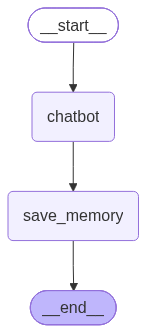

In [54]:
graph

In [55]:
# ============================================================
# CHAT FUNCTION
# ============================================================

def chat(
    user_id,
    thread_id,
    message
):

    config = {
        "configurable": {

            "thread_id": thread_id,

            "user_id": user_id
        }
    }


    result = graph.invoke(

        {
            "messages": [
                {
                    "role": "user",
                    "content": message
                }
            ]
        },

        config=config
    )


    return (
        result["messages"][-1].content
    )

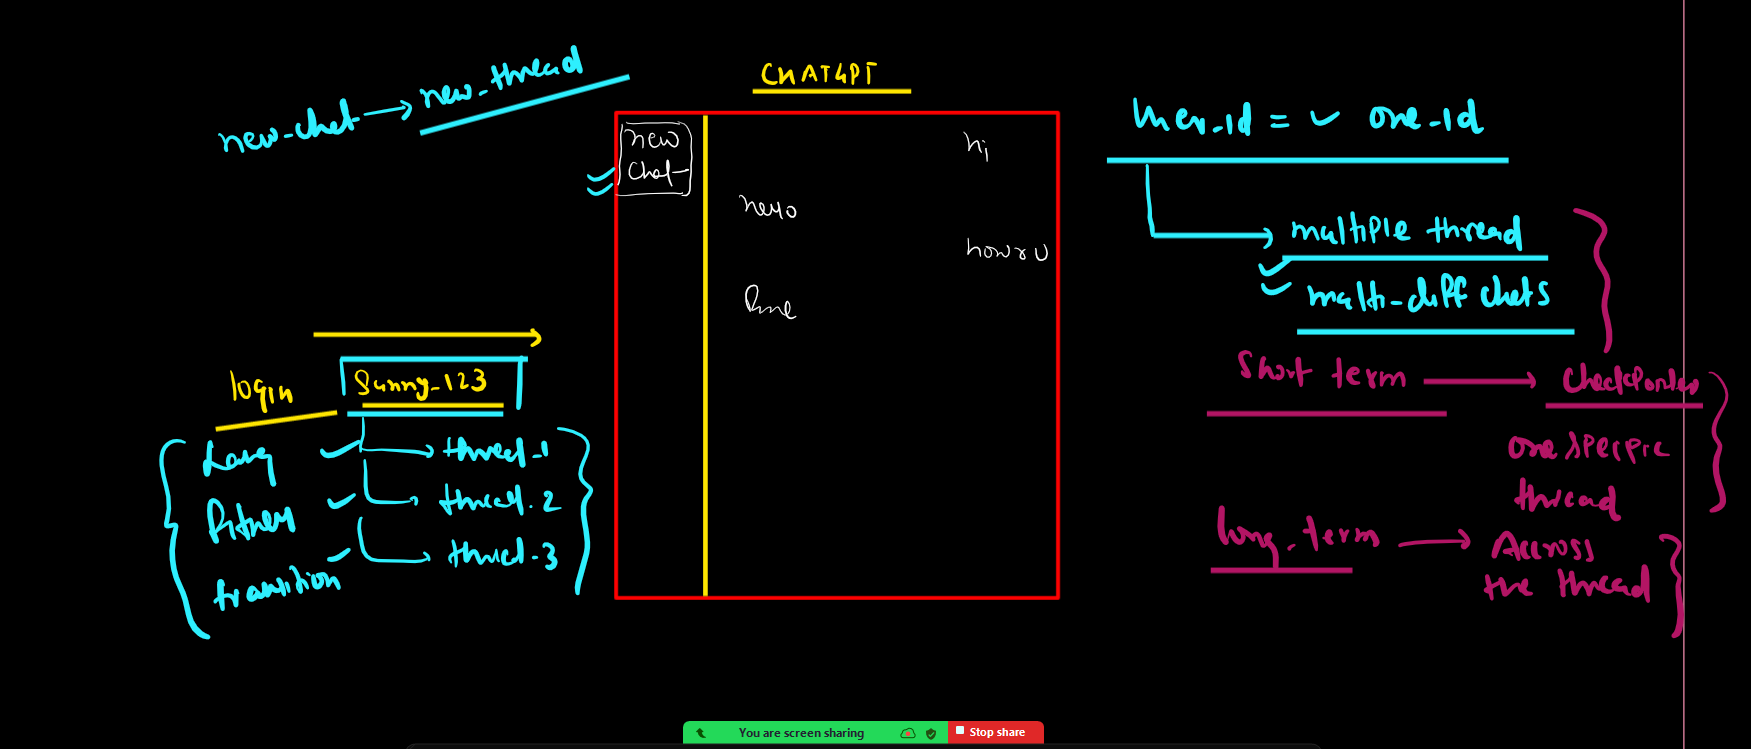

In [56]:
# ============================================================
# TEST + MEMORY VISUALIZATION
# Run this cell immediately after the chat() function cell.
# ============================================================

test_user_id = "sunny_langgraph_test"
thread_1 = "memory_test_thread_1"
thread_2 = "memory_test_thread_2"

In [57]:
# ------------------------------------------------------------
# 1. STORE FACTS IN THREAD 1
# ------------------------------------------------------------

print("\nTEST 1 - Store user information")
print(
    chat(
        user_id=test_user_id,
        thread_id=thread_1,
        message=(
            "My name is Sunny. I prefer concise explanations, "
            "my favorite language is Python, and I am building "
            "an Agentic RAG project."
        )
    )
)



TEST 1 - Store user information
Got it, Sunny! I’ll keep explanations concise and Python-focused for your Agentic RAG project. How can I assist you today?


In [58]:
# ------------------------------------------------------------
# 2. SAME THREAD: TEST SHORT-TERM MEMORY
# ------------------------------------------------------------

print("\nTEST 2 - Same-thread memory")
print(
    chat(
        user_id=test_user_id,
        thread_id=thread_1,
        message=(
            "What is my name, which language do I prefer, "
            "and what project am I building?"
        )
    )
)



TEST 2 - Same-thread memory
Your name is Sunny, you prefer Python, and you are building an Agentic RAG project.


In [59]:
# ------------------------------------------------------------
# 3. NEW THREAD: TEST LONG-TERM MEMORY
# ------------------------------------------------------------

print("\nTEST 3 - Cross-thread long-term memory")
print(
    chat(
        user_id=test_user_id,
        thread_id=thread_2,
        message="What do you remember about me?"
    )
)


TEST 3 - Cross-thread long-term memory
I remember that your name is Sunny, you prefer concise explanations, your favorite programming language is Python, and you are working on a project named Agentic RAG.


In [61]:
# ------------------------------------------------------------
# 4. VIEW SHORT-TERM MEMORY FOR A THREAD
# ------------------------------------------------------------

def show_thread_memory(user_id, thread_id):

    config = {
        "configurable": {
            "user_id": user_id,
            "thread_id": thread_id
        }
    }

    snapshot = graph.get_state(config)
    messages = snapshot.values.get("messages", [])

    print("\n" + "=" * 50)
    print(f"SHORT-TERM MEMORY | THREAD: {thread_id}")
    print("=" * 50)

    if not messages:
        print("No messages stored for this thread.")
        return

    for number, message in enumerate(messages, start=1):
        print(
            f"{number}. {message.type.title()}: "
            f"{message.content}"
        )


In [62]:
# ------------------------------------------------------------
# 5. VIEW LONG-TERM MEMORY FOR A USER
# ------------------------------------------------------------

def show_long_term_memory(user_id):

    memories = store.search(
        ("memories", user_id),
        limit=100
    )

    print("\n" + "=" * 50)
    print(f"LONG-TERM MEMORY | USER: {user_id}")
    print("=" * 50)

    if not memories:
        print("No long-term memories stored for this user.")
        return

    for number, memory in enumerate(memories, start=1):
        print(f"{number}. {memory.value}")

In [63]:
# Display both thread histories and extracted user memories.
show_thread_memory(test_user_id, thread_1)


SHORT-TERM MEMORY | THREAD: memory_test_thread_1
1. Human: My name is Sunny. I prefer concise explanations, my favorite language is Python, and I am building an Agentic RAG project.
2. Ai: Got it, Sunny! I’ll keep explanations concise and Python-focused for your Agentic RAG project. How can I assist you today?
3. Human: What is my name, which language do I prefer, and what project am I building?
4. Ai: Your name is Sunny, you prefer Python, and you are building an Agentic RAG project.


In [64]:
show_thread_memory(test_user_id, thread_2)


SHORT-TERM MEMORY | THREAD: memory_test_thread_2
1. Human: What do you remember about me?
2. Ai: I remember that your name is Sunny, you prefer concise explanations, your favorite programming language is Python, and you are working on a project named Agentic RAG.


In [65]:
show_long_term_memory(test_user_id)


LONG-TERM MEMORY | USER: sunny_langgraph_test
1. {'kind': 'Memory', 'content': {'content': "User's name is Sunny."}}
2. {'kind': 'Memory', 'content': {'content': 'User is working on a project named Agentic RAG.'}}
3. {'kind': 'Memory', 'content': {'content': "User's favorite programming language is Python."}}
4. {'kind': 'Memory', 'content': {'content': 'User prefers concise explanations.'}}
5. {'kind': 'Memory', 'content': {'content': "User's name is Sunny."}}
6. {'kind': 'Memory', 'content': {'content': 'User prefers concise explanations.'}}
7. {'kind': 'Memory', 'content': {'content': 'User is working on a project named Agentic RAG.'}}
8. {'kind': 'Memory', 'content': {'content': "User's favorite programming language is Python."}}


In [66]:

import sqlite3
import uuid

from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage

from langgraph.graph import (
    StateGraph,
    MessagesState,
    START,
    END
)

from langgraph.checkpoint.sqlite import (
    SqliteSaver
)

In [67]:

# ============================================================
# MODEL
# ============================================================

model = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0
)

In [69]:
# ============================================================
# SHORT-TERM MEMORY
# SQLITE CHECKPOINTER
# ============================================================
#
# Stores conversation state based on thread_id.
#
# Unlike InMemorySaver, this survives
# application restart.
# ============================================================

checkpoint_connection = sqlite3.connect(
    "checkpoints.db",
    check_same_thread=False
)

checkpointer = SqliteSaver(
    checkpoint_connection
)


In [94]:
# ============================================================
# LONG-TERM MEMORY
# CUSTOM SQLITE STORAGE
# ============================================================

class SQLiteLongTermMemory:

    def __init__(
        self,
        db_path="long_term_memory.db"
    ):

        self.db_path = db_path

        self.create_table()


    def connect(self):

        return sqlite3.connect(
            self.db_path
        )


    def create_table(self):

        with self.connect() as connection:

            connection.execute(
                """
                CREATE TABLE IF NOT EXISTS memories (

                    memory_id TEXT PRIMARY KEY,

                    user_id TEXT NOT NULL,

                    content TEXT NOT NULL,

                    created_at TIMESTAMP
                    DEFAULT CURRENT_TIMESTAMP

                )
                """
            )

            connection.commit()


    # --------------------------------------------------------
    # SAVE MEMORY
    # --------------------------------------------------------

    def add_memory(
        self,
        user_id,
        content
    ):

        # Avoid duplicate memories

        existing_memories = (
            self.get_memories(
                user_id
            )
        )

        if content in existing_memories:
            return


        memory_id = str(
            uuid.uuid4()
        )


        with self.connect() as connection:

            connection.execute(
                """
                INSERT INTO memories (
                    memory_id,
                    user_id,
                    content
                )

                VALUES (?, ?, ?)
                """,

                (
                    memory_id,
                    user_id,
                    content
                )
            )

            connection.commit()


    # --------------------------------------------------------
    # GET USER MEMORIES
    # --------------------------------------------------------

    def get_memories(
        self,
        user_id
    ):

        with self.connect() as connection:

            rows = connection.execute(
                """
                SELECT content

                FROM memories

                WHERE user_id = ?

                ORDER BY created_at
                """,

                (
                    user_id,
                )

            ).fetchall()


        return [
            row[0]
            for row in rows
        ]


In [95]:
# Create long-term memory object

long_term_memory = (
    SQLiteLongTermMemory()
)

In [96]:
long_term_memory.get_memories("test_user_1")

[]

In [97]:

# ============================================================
# MEMORY EXTRACTION SCHEMA
# ============================================================

class ExtractedMemories(BaseModel):

    memories: List[str] = Field(
        default_factory=list,
        description="""
        Important long-term information
        learned about the user.
        """
    )


In [98]:

# ============================================================
# MEMORY EXTRACTION MODEL
# ============================================================

memory_extractor = (
    model.with_structured_output(
        ExtractedMemories
    )
)


In [99]:
# ============================================================
# AUTOMATIC MEMORY EXTRACTION
# ============================================================

def extract_memories(
    user_message
):

    prompt = f"""
Analyze the following user message.

User message:
{user_message}

Extract only useful long-term information
about the user.

Examples of useful memory:

- preferences
- personal facts
- goals
- projects
- skills
- important decisions

Do NOT store:

- greetings
- temporary questions
- general knowledge questions
- unnecessary conversation

If there is nothing useful to remember,
return an empty list.
"""


    result = memory_extractor.invoke(
        prompt
    )


    return result.memories


In [100]:
# ============================================================
# CHATBOT NODE
# ============================================================

def chatbot(
    state: MessagesState,
    config
):

    # --------------------------------------------------------
    # Get user_id
    # --------------------------------------------------------

    user_id = (
        config["configurable"]["user_id"]
    )


    # --------------------------------------------------------
    # Get long-term user memories
    # --------------------------------------------------------

    memories = (
        long_term_memory.get_memories(
            user_id
        )
    )


    if memories:

        memory_text = "\n".join(
            f"- {memory}"
            for memory in memories
        )

    else:

        memory_text = (
            "No saved long-term memories."
        )


    # --------------------------------------------------------
    # System message
    # --------------------------------------------------------

    system_message = SystemMessage(
        content=f"""
You are a helpful AI assistant.

Here is useful long-term information
about the user:

{memory_text}

Use these memories only when relevant.

The remaining messages contain the
conversation history for the current
thread.
"""
    )


    # --------------------------------------------------------
    # Generate response
    # --------------------------------------------------------

    response = model.invoke(
        [
            system_message,
            *state["messages"]
        ]
    )


    return {
        "messages": [
            response
        ]
    }


In [101]:
# ============================================================
# MEMORY UPDATE NODE
# ============================================================

def save_long_term_memory(
    state: MessagesState,
    config
):

    user_id = (
        config["configurable"]["user_id"]
    )


    # Find latest user message

    latest_user_message = None


    for message in reversed(
        state["messages"]
    ):

        if message.type == "human":

            latest_user_message = (
                message.content
            )

            break


    if not latest_user_message:

        return {}


    # --------------------------------------------------------
    # Automatically extract useful memories
    # --------------------------------------------------------

    memories = extract_memories(
        latest_user_message
    )


    # --------------------------------------------------------
    # Save memories into SQLite
    # --------------------------------------------------------

    for memory in memories:

        long_term_memory.add_memory(
            user_id,
            memory
        )


    return {}


In [102]:
# ============================================================
# BUILD LANGGRAPH
# ============================================================

builder = StateGraph(
    MessagesState
)


builder.add_node(
    "chatbot",
    chatbot
)


builder.add_node(
    "save_memory",
    save_long_term_memory
)


builder.add_edge(
    START,
    "chatbot"
)


builder.add_edge(
    "chatbot",
    "save_memory"
)


builder.add_edge(
    "save_memory",
    END
)


In [103]:
# ============================================================
# COMPILE GRAPH
# ============================================================

graph = builder.compile(
    checkpointer=checkpointer
)



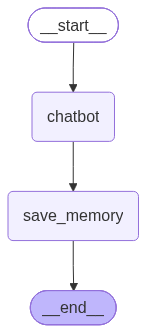

In [104]:
graph

In [105]:
# ============================================================
# CHAT FUNCTION
# ============================================================

def chat(
    user_id,
    thread_id,
    message
):

    config = {

        "configurable": {

            # WHO is the user?
            "user_id": user_id,

            # WHICH conversation?
            "thread_id": thread_id
        }
    }


    result = graph.invoke(

        {
            "messages": [
                {
                    "role": "user",
                    "content": message
                }
            ]
        },

        config=config
    )


    return (
        result["messages"][-1].content
    )


In [106]:
# ============================================================
# TEST
# ============================================================


# ------------------------------------------------------------
# THREAD 1
# ------------------------------------------------------------

print(
    chat(
        user_id="sunny_123",
        thread_id="thread_1",
        message=(
            "My favorite programming "
            "language is Python."
        )
    )
)

That's great! Python is a versatile and popular programming language known for its readability and wide range of applications, from web development to data science and machine learning. Do you have any favorite Python projects or topics you'd like to discuss?


In [107]:

print(
    chat(
        user_id="sunny_123",
        thread_id="thread_1",
        message=(
            "I am currently building "
            "an Agentic RAG application."
        )
    )
)


That sounds like an exciting project! Agentic RAG (Retrieval-Augmented Generation) applications combine retrieval of relevant information with generative models to produce more accurate and context-aware responses.

Are you using Python for this project? If so, I can help with libraries, architecture design, or code examples related to building an Agentic RAG system. What specific part are you working on or need assistance with?


In [108]:
# ------------------------------------------------------------
# SAME THREAD
# Checkpointer remembers conversation
# ------------------------------------------------------------

print(
    chat(
        user_id="sunny_123",
        thread_id="thread_1",
        message=(
            "What project am I building?"
        )
    )
)


You are currently building an Agentic RAG (Retrieval-Augmented Generation) application.


In [109]:
# ------------------------------------------------------------
# NEW THREAD
# Same user
#
# Thread history is different,
# but SQLite long-term memory is shared.
# ------------------------------------------------------------

print(
    chat(
        user_id="sunny_123",
        thread_id="thread_2",
        message=(
            "Which programming language "
            "do I prefer?"
        )
    )
)

You prefer Python as your programming language.


In [110]:
# ------------------------------------------------------------
# DIFFERENT USER
# ------------------------------------------------------------

print(
    chat(
        user_id="user_456",
        thread_id="thread_1",
        message=(
            "Which programming language "
            "do I prefer?"
        )
    )
)

You prefer the Python programming language.
